# Homework 2 — Problem 2

In [14]:
# Check GPU / device
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## Step 1 — Imports and settings

In [15]:
import os
import time
import math
import random
import zipfile
import urllib.request
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Main settings
# -----------------------------
FAST_MODE = True      # First run with True. For final results, change to False
SEED = 42

EPOCHS = 2 if FAST_MODE else 10
MAX_TRAIN_SAMPLES = 8000 if FAST_MODE else 50000
MAX_VAL_SAMPLES = 2000 if FAST_MODE else 5000

BATCH_SIZE = 64
EMBEDDING_DIM = 64
BASE_HIDDEN_SIZE = 128
BASE_NUM_LAYERS = 1
BASE_FC_HIDDEN_SIZE = 0
DROPOUT = 0.2
LEARNING_RATE = 0.002
WEIGHT_DECAY = 0.0
GRAD_CLIP = 1.0
VAL_FRACTION = 0.10

GENERATE_LENGTH = 300
TEMPERATURE = 0.8
SEED_TEXT = "ROMEO:"

OUT_DIR = Path("problem2_outputs")
CKPT_DIR = OUT_DIR / "checkpoints"
OUT_DIR.mkdir(exist_ok=True)
CKPT_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("FAST_MODE:", FAST_MODE)
print("Epochs:", EPOCHS)
print("Max train samples:", MAX_TRAIN_SAMPLES)
print("Max val samples:", MAX_VAL_SAMPLES)

Device: cuda
FAST_MODE: True
Epochs: 2
Max train samples: 8000
Max val samples: 2000


In [16]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

## Step 2 — Download Tiny Shakespeare

In [17]:
TINY_SHAKESPEARE_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
DATA_PATH = DATA_DIR / "tiny_shakespeare.txt"

if not DATA_PATH.exists():
    print("Downloading Tiny Shakespeare...")
    urllib.request.urlretrieve(TINY_SHAKESPEARE_URL, DATA_PATH)
else:
    print("Tiny Shakespeare already exists.")

text = DATA_PATH.read_text(encoding="utf-8")
print("Total characters:", len(text))
print("First 500 characters:")
print(text[:500])

Tiny Shakespeare already exists.
Total characters: 1115394
First 500 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


## Step 3 — Character vocabulary and dataset loader

In [18]:
@dataclass
class CharVocab:
    stoi: Dict[str, int]
    itos: List[str]

    @classmethod
    def build(cls, text: str):
        chars = sorted(set(text))
        stoi = {ch: idx for idx, ch in enumerate(chars)}
        return cls(stoi=stoi, itos=chars)

    def encode(self, s: str) -> List[int]:
        return [self.stoi[ch] for ch in s]

    def decode(self, ids: List[int]) -> str:
        return "".join(self.itos[i] for i in ids)

    @property
    def size(self) -> int:
        return len(self.itos)


class CharSequenceDataset(Dataset):
    """Next-character prediction dataset.

    x = sequence of length seq_len
    y = next character after x
    """
    def __init__(self, encoded_text: List[int], seq_len: int, max_samples: Optional[int] = None):
        if len(encoded_text) <= seq_len:
            raise ValueError("Text is too short for this sequence length.")
        self.encoded_text = encoded_text
        self.seq_len = seq_len
        self.n = len(encoded_text) - seq_len
        if max_samples is not None:
            self.n = min(self.n, max_samples)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        x = torch.tensor(self.encoded_text[idx:idx + self.seq_len], dtype=torch.long)
        y = torch.tensor(self.encoded_text[idx + self.seq_len], dtype=torch.long)
        return x, y


def make_loaders(text: str, seq_len: int, batch_size: int,
                 val_fraction: float = 0.1,
                 max_train_samples: Optional[int] = None,
                 max_val_samples: Optional[int] = None):
    vocab = CharVocab.build(text)
    split_idx = int(len(text) * (1.0 - val_fraction))

    # Keep a small overlap before validation
    train_text = text[:split_idx]
    val_text = text[max(0, split_idx - seq_len):]

    train_ids = vocab.encode(train_text)
    val_ids = vocab.encode(val_text)

    train_ds = CharSequenceDataset(train_ids, seq_len, max_samples=max_train_samples)
    val_ds = CharSequenceDataset(val_ids, seq_len, max_samples=max_val_samples)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)
    return vocab, train_loader, val_loader

# Quick check
vocab_check, train_check, val_check = make_loaders(text, seq_len=20, batch_size=64,
                                                  max_train_samples=1000,
                                                  max_val_samples=200)
print("Vocabulary size:", vocab_check.size)
print("Train batches:", len(train_check))
print("Validation batches:", len(val_check))
xb, yb = next(iter(train_check))
print("Input batch shape:", xb.shape)
print("Target batch shape:", yb.shape)

Vocabulary size: 65
Train batches: 16
Validation batches: 4
Input batch shape: torch.Size([64, 20])
Target batch shape: torch.Size([64])


## Step 4 — LSTM/GRU model

In [19]:
class CharRNNModel(nn.Module):
    def __init__(self, vocab_size: int, model_type: str = "LSTM",
                 embedding_dim: int = 64, hidden_size: int = 128,
                 num_layers: int = 1, fc_hidden_size: int = 0,
                 dropout: float = 0.0):
        super().__init__()
        model_type = model_type.upper()
        if model_type not in {"LSTM", "GRU"}:
            raise ValueError("Problem 2 only uses LSTM and GRU.")

        self.model_type = model_type
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.fc_hidden_size = fc_hidden_size
        self.dropout = dropout

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        rnn_dropout = dropout if num_layers > 1 else 0.0
        recurrent_class = nn.LSTM if model_type == "LSTM" else nn.GRU
        self.recurrent = recurrent_class(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=rnn_dropout
        )

        if fc_hidden_size and fc_hidden_size > 0:
            self.fc = nn.Sequential(
                nn.Linear(hidden_size, fc_hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(fc_hidden_size, vocab_size)
            )
        else:
            self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)           # [batch, seq_len, embedding_dim]
        out, _ = self.recurrent(emb)      # [batch, seq_len, hidden_size]
        last_hidden = out[:, -1, :]       # [batch, hidden_size]
        logits = self.fc(last_hidden)     # [batch, vocab_size]
        return logits


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_size_mb(model: nn.Module) -> float:
    return count_parameters(model) * 4 / (1024 ** 2)

# Quick model check
model_check = CharRNNModel(vocab_size=vocab_check.size, model_type="LSTM")
print(model_check)
print("Trainable parameters:", count_parameters(model_check))
print("Model size MB:", model_size_mb(model_check))

CharRNNModel(
  (embedding): Embedding(65, 64)
  (recurrent): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=65, bias=True)
)
Trainable parameters: 111873
Model size MB: 0.4267616271972656


## Step 5 — Complexity estimates

In [20]:
def approximate_forward_macs_per_sequence(model_type: str, seq_len: int, vocab_size: int,
                                           embedding_dim: int, hidden_size: int,
                                           num_layers: int, fc_hidden_size: int = 0) -> int:
    """Approximate multiply-add operations for one sequence.

    LSTM has 4 gates. GRU has 3 gates.
    For each recurrent layer and each time step:
      gates * (input_size * hidden_size + hidden_size * hidden_size)
    Then add final classifier cost.
    """
    model_type = model_type.upper()
    gates = 4 if model_type == "LSTM" else 3

    recurrent_macs = 0
    for layer in range(num_layers):
        input_size = embedding_dim if layer == 0 else hidden_size
        recurrent_macs += seq_len * gates * ((input_size * hidden_size) + (hidden_size * hidden_size))

    if fc_hidden_size and fc_hidden_size > 0:
        classifier_macs = hidden_size * fc_hidden_size + fc_hidden_size * vocab_size
    else:
        classifier_macs = hidden_size * vocab_size

    return int(recurrent_macs + classifier_macs)


def complexity_summary(model_type: str, seq_len: int, vocab_size: int,
                       embedding_dim: int, hidden_size: int,
                       num_layers: int, fc_hidden_size: int = 0):
    macs = approximate_forward_macs_per_sequence(
        model_type=model_type,
        seq_len=seq_len,
        vocab_size=vocab_size,
        embedding_dim=embedding_dim,
        hidden_size=hidden_size,
        num_layers=num_layers,
        fc_hidden_size=fc_hidden_size,
    )
    return {
        "approx_forward_macs_per_sequence": macs,
        "complexity_note": f"Approx. O(seq_len * layers * gates * (input_size*hidden + hidden^2)); gates=4 for LSTM, 3 for GRU."
    }

print(complexity_summary("LSTM", 30, vocab_check.size, 64, 128, 1, 0))
print(complexity_summary("GRU", 30, vocab_check.size, 64, 128, 1, 0))

{'approx_forward_macs_per_sequence': 2957440, 'complexity_note': 'Approx. O(seq_len * layers * gates * (input_size*hidden + hidden^2)); gates=4 for LSTM, 3 for GRU.'}
{'approx_forward_macs_per_sequence': 2220160, 'complexity_note': 'Approx. O(seq_len * layers * gates * (input_size*hidden + hidden^2)); gates=4 for LSTM, 3 for GRU.'}


## Step 6 — Training, validation, timing, and generation functions

In [21]:
def evaluate_model(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            preds = logits.argmax(dim=1)

            total_loss += loss.item() * x.size(0)
            total_correct += (preds == y).sum().item()
            total_count += x.size(0)

    return total_loss / total_count, total_correct / total_count


def train_model(model, train_loader, val_loader, device, epochs, learning_rate,
                weight_decay=0.0, grad_clip=1.0, checkpoint_path=None):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    best_val_acc = -1.0
    best_state = None
    history = []

    if device.type == "cuda":
        torch.cuda.synchronize()
    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_count = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()

            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            total_loss += loss.item() * x.size(0)
            total_count += x.size(0)

        train_loss = total_loss / total_count
        val_loss, val_acc = evaluate_model(model, val_loader, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
        })

        print(f"Epoch {epoch:02d}/{epochs} | train loss {train_loss:.4f} | val loss {val_loss:.4f} | val acc {val_acc:.4f}")

    if device.type == "cuda":
        torch.cuda.synchronize()
    training_time_sec = time.perf_counter() - start_time

    if best_state is not None:
        model.load_state_dict(best_state)

    if checkpoint_path is not None:
        torch.save(model.state_dict(), checkpoint_path)

    return {
        "history": history,
        "final_train_loss": history[-1]["train_loss"],
        "final_val_loss": history[-1]["val_loss"],
        "best_val_accuracy": best_val_acc,
        "training_time_sec": training_time_sec,
    }


def measure_inference_time(model, loader, device, batches=20):
    model.eval()
    model.to(device)
    times = []

    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            if i >= batches:
                break
            x = x.to(device)
            if device.type == "cuda":
                torch.cuda.synchronize()
            start = time.perf_counter()
            _ = model(x)
            if device.type == "cuda":
                torch.cuda.synchronize()
            times.append(time.perf_counter() - start)

    if len(times) == 0:
        return float("nan")
    return 1000.0 * sum(times) / len(times)


def generate_text(model, vocab, seed_text="ROMEO:", length=300, temperature=0.8, device="cpu"):
    model.eval()
    model.to(device)
    generated = seed_text

    with torch.no_grad():
        for _ in range(length):

            safe_text = "".join(ch for ch in generated if ch in vocab.stoi)
            input_ids = vocab.encode(safe_text[-100:])
            x = torch.tensor([input_ids], dtype=torch.long).to(device)
            logits = model(x)[0] / temperature
            probs = torch.softmax(logits, dim=0)
            next_id = torch.multinomial(probs, num_samples=1).item()
            generated += vocab.itos[next_id]

    return generated

## Step 7 — Build the experiment plan

In [22]:
def build_experiment_plan():
    experiments = []

    # Part 1: LSTM and GRU with sequence lengths 20 and 30
    for model_type in ["LSTM", "GRU"]:
        for seq_len in [20, 30]:
            experiments.append({
                "part": "P2-Part1-sequence-comparison",
                "model_type": model_type,
                "seq_len": seq_len,
                "embedding_dim": EMBEDDING_DIM,
                "hidden_size": BASE_HIDDEN_SIZE,
                "num_layers": BASE_NUM_LAYERS,
                "fc_hidden_size": BASE_FC_HIDDEN_SIZE,
                "dropout": DROPOUT,
            })

    # Part 2: hyperparameter study at sequence length 30
    # Baseline is included
    hyperparameter_variants = [
        ("baseline", BASE_HIDDEN_SIZE, BASE_NUM_LAYERS, BASE_FC_HIDDEN_SIZE),
        ("larger_hidden_states", BASE_HIDDEN_SIZE * 2, BASE_NUM_LAYERS, BASE_FC_HIDDEN_SIZE),
        ("more_hidden_layers", BASE_HIDDEN_SIZE, BASE_NUM_LAYERS + 1, BASE_FC_HIDDEN_SIZE),
        ("fc_hidden_layer", BASE_HIDDEN_SIZE, BASE_NUM_LAYERS, 128),
    ]

    for model_type in ["LSTM", "GRU"]:
        for label, hidden_size, num_layers, fc_hidden_size in hyperparameter_variants:
            experiments.append({
                "part": f"P2-Part2-{label}",
                "model_type": model_type,
                "seq_len": 30,
                "embedding_dim": EMBEDDING_DIM,
                "hidden_size": hidden_size,
                "num_layers": num_layers,
                "fc_hidden_size": fc_hidden_size,
                "dropout": DROPOUT,
            })

    # Part 3: sequence length 50
    for model_type in ["LSTM", "GRU"]:
        experiments.append({
            "part": "P2-Part3-seq50",
            "model_type": model_type,
            "seq_len": 50,
            "embedding_dim": EMBEDDING_DIM,
            "hidden_size": BASE_HIDDEN_SIZE,
            "num_layers": BASE_NUM_LAYERS,
            "fc_hidden_size": BASE_FC_HIDDEN_SIZE,
            "dropout": DROPOUT,
        })

    return experiments

experiments = build_experiment_plan()
print("Number of experiments:", len(experiments))
pd.DataFrame(experiments)

Number of experiments: 14


,part,model_type,seq_len,embedding_dim,hidden_size,num_layers,fc_hidden_size,dropout
0,P2-Part1-sequence-comparison,LSTM,20,64,128,1,0,0.2
1,P2-Part1-sequence-comparison,LSTM,30,64,128,1,0,0.2
2,P2-Part1-sequence-comparison,GRU,20,64,128,1,0,0.2
3,P2-Part1-sequence-comparison,GRU,30,64,128,1,0,0.2
4,P2-Part2-baseline,LSTM,30,64,128,1,0,0.2
5,P2-Part2-larger_hidden_states,LSTM,30,64,256,1,0,0.2
6,P2-Part2-more_hidden_layers,LSTM,30,64,128,2,0,0.2
7,P2-Part2-fc_hidden_layer,LSTM,30,64,128,1,128,0.2
8,P2-Part2-baseline,GRU,30,64,128,1,0,0.2
9,P2-Part2-larger_hidden_states,GRU,30,64,256,1,0,0.2


## Step 8 — Run all experiments

In [23]:
summary_rows = []
history_rows = []
sample_sections = []

for exp_idx, exp in enumerate(experiments, start=1):
    print("\n" + "=" * 90)
    print(f"Experiment {exp_idx}/{len(experiments)}")
    print(exp)

    vocab, train_loader, val_loader = make_loaders(
        text=text,
        seq_len=exp["seq_len"],
        batch_size=BATCH_SIZE,
        val_fraction=VAL_FRACTION,
        max_train_samples=MAX_TRAIN_SAMPLES,
        max_val_samples=MAX_VAL_SAMPLES,
    )

    model = CharRNNModel(
        vocab_size=vocab.size,
        model_type=exp["model_type"],
        embedding_dim=exp["embedding_dim"],
        hidden_size=exp["hidden_size"],
        num_layers=exp["num_layers"],
        fc_hidden_size=exp["fc_hidden_size"],
        dropout=exp["dropout"],
    )

    checkpoint_name = (
        f"{exp_idx:02d}_{exp['part']}_{exp['model_type']}_"
        f"seq{exp['seq_len']}_h{exp['hidden_size']}_"
        f"layers{exp['num_layers']}_fc{exp['fc_hidden_size']}.pt"
    ).replace("/", "-")

    result = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        grad_clip=GRAD_CLIP,
        checkpoint_path=CKPT_DIR / checkpoint_name,
    )

    inference_ms = measure_inference_time(model, val_loader, DEVICE, batches=20)
    params = count_parameters(model)
    size_mb = model_size_mb(model)
    comp = complexity_summary(
        model_type=exp["model_type"],
        seq_len=exp["seq_len"],
        vocab_size=vocab.size,
        embedding_dim=exp["embedding_dim"],
        hidden_size=exp["hidden_size"],
        num_layers=exp["num_layers"],
        fc_hidden_size=exp["fc_hidden_size"],
    )

    generated = generate_text(
        model=model,
        vocab=vocab,
        seed_text=SEED_TEXT,
        length=GENERATE_LENGTH,
        temperature=TEMPERATURE,
        device=DEVICE,
    )

    sample_sections.append("=" * 90)
    sample_sections.append(str(exp))
    sample_sections.append(generated)
    sample_sections.append("")

    summary_row = {
        "problem": "Problem 2",
        **exp,
        "vocab_size": vocab.size,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "max_train_samples": MAX_TRAIN_SAMPLES,
        "max_val_samples": MAX_VAL_SAMPLES,
        "final_train_loss": result["final_train_loss"],
        "final_val_loss": result["final_val_loss"],
        "best_val_accuracy": result["best_val_accuracy"],
        "training_time_sec": result["training_time_sec"],
        "inference_ms_per_batch": inference_ms,
        "trainable_parameters": params,
        "model_size_mb": size_mb,
        **comp,
    }
    summary_rows.append(summary_row)

    for hist in result["history"]:
        history_rows.append({
            "experiment_index": exp_idx,
            "part": exp["part"],
            "model_type": exp["model_type"],
            "seq_len": exp["seq_len"],
            "hidden_size": exp["hidden_size"],
            "num_layers": exp["num_layers"],
            "fc_hidden_size": exp["fc_hidden_size"],
            **hist,
        })

summary_df = pd.DataFrame(summary_rows)
history_df = pd.DataFrame(history_rows)

summary_csv = OUT_DIR / "problem2_results.csv"
history_csv = OUT_DIR / "problem2_epoch_history.csv"
samples_txt = OUT_DIR / "problem2_generated_samples.txt"

summary_df.to_csv(summary_csv, index=False)
history_df.to_csv(history_csv, index=False)
samples_txt.write_text("\n".join(sample_sections), encoding="utf-8")

print("\nSaved:")
print(summary_csv)
print(history_csv)
print(samples_txt)

summary_df[[
    "part", "model_type", "seq_len", "hidden_size", "num_layers", "fc_hidden_size",
    "final_train_loss", "final_val_loss", "best_val_accuracy", "training_time_sec",
    "inference_ms_per_batch", "trainable_parameters", "model_size_mb",
    "approx_forward_macs_per_sequence"
]]


Experiment 1/14
{'part': 'P2-Part1-sequence-comparison', 'model_type': 'LSTM', 'seq_len': 20, 'embedding_dim': 64, 'hidden_size': 128, 'num_layers': 1, 'fc_hidden_size': 0, 'dropout': 0.2}
Epoch 01/2 | train loss 2.8781 | val loss 2.7766 | val acc 0.2615
Epoch 02/2 | train loss 2.2913 | val loss 2.6533 | val acc 0.3015

Experiment 2/14
{'part': 'P2-Part1-sequence-comparison', 'model_type': 'LSTM', 'seq_len': 30, 'embedding_dim': 64, 'hidden_size': 128, 'num_layers': 1, 'fc_hidden_size': 0, 'dropout': 0.2}
Epoch 01/2 | train loss 2.8870 | val loss 2.7648 | val acc 0.2755
Epoch 02/2 | train loss 2.2992 | val loss 2.6822 | val acc 0.2900

Experiment 3/14
{'part': 'P2-Part1-sequence-comparison', 'model_type': 'GRU', 'seq_len': 20, 'embedding_dim': 64, 'hidden_size': 128, 'num_layers': 1, 'fc_hidden_size': 0, 'dropout': 0.2}
Epoch 01/2 | train loss 2.7458 | val loss 2.6974 | val acc 0.2805
Epoch 02/2 | train loss 2.1818 | val loss 2.5733 | val acc 0.2985

Experiment 4/14
{'part': 'P2-Part1

,part,model_type,seq_len,hidden_size,num_layers,fc_hidden_size,final_train_loss,final_val_loss,best_val_accuracy,training_time_sec,inference_ms_per_batch,trainable_parameters,model_size_mb,approx_forward_macs_per_sequence
0,P2-Part1-sequence-comparison,LSTM,20,128,1,0,2.291331,2.653299,0.3015,0.890235,0.705546,111873,0.426762,1974400
1,P2-Part1-sequence-comparison,LSTM,30,128,1,0,2.299169,2.682173,0.2900,0.877338,0.648562,111873,0.426762,2957440
2,P2-Part1-sequence-comparison,GRU,20,128,1,0,2.181819,2.573286,0.2985,0.818190,0.453621,87041,0.332035,1482880
3,P2-Part1-sequence-comparison,GRU,30,128,1,0,2.167739,2.644323,0.3035,0.872770,0.712330,87041,0.332035,2220160
4,P2-Part2-baseline,LSTM,30,128,1,0,2.274721,2.675101,0.2895,0.895908,0.709662,111873,0.426762,2957440
5,P2-Part2-larger_hidden_states,LSTM,30,256,1,0,2.185616,2.574545,0.3070,1.128176,0.921616,350593,1.337406,9847040
6,P2-Part2-more_hidden_layers,LSTM,30,128,2,0,2.383347,2.704070,0.2925,1.476866,1.187181,243969,0.930668,6889600
7,P2-Part2-fc_hidden_layer,LSTM,30,128,1,128,2.321747,2.723065,0.2985,0.969313,0.641712,128385,0.489750,2973824
8,P2-Part2-baseline,GRU,30,128,1,0,2.173926,2.577122,0.3165,0.849303,0.527095,87041,0.332035,2220160
9,P2-Part2-larger_hidden_states,GRU,30,256,1,0,2.047842,2.519946,0.3330,1.084548,0.850819,268161,1.022953,7389440


## Step 9 — Plot training loss and validation accuracy curves

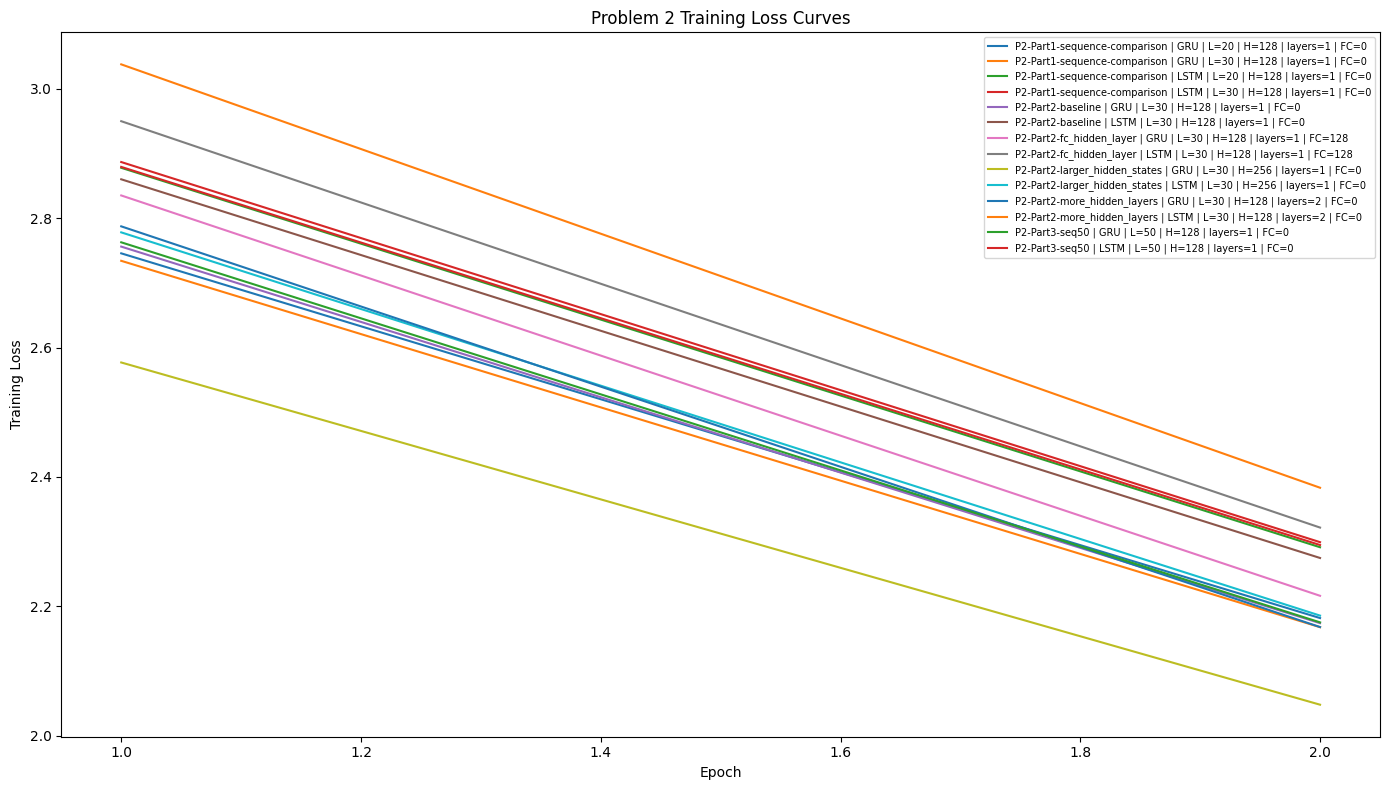

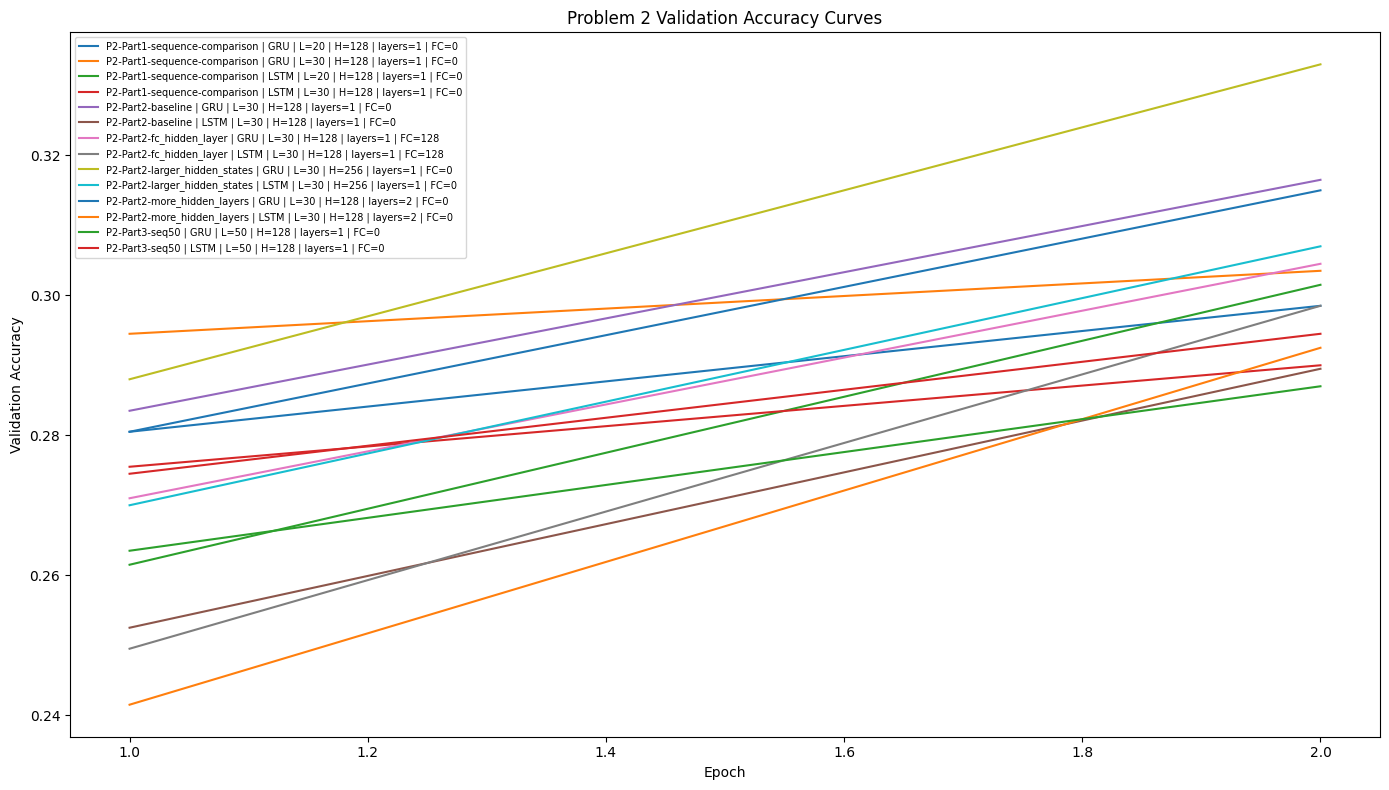

Saved: problem2_outputs/problem2_loss_curves.png
Saved: problem2_outputs/problem2_accuracy_curves.png


In [24]:
history_plot_df = history_df.copy()
history_plot_df["label"] = (
    history_plot_df["part"].astype(str)
    + " | " + history_plot_df["model_type"].astype(str)
    + " | L=" + history_plot_df["seq_len"].astype(str)
    + " | H=" + history_plot_df["hidden_size"].astype(str)
    + " | layers=" + history_plot_df["num_layers"].astype(str)
    + " | FC=" + history_plot_df["fc_hidden_size"].astype(str)
)

plt.figure(figsize=(14, 8))
for label, group in history_plot_df.groupby("label"):
    plt.plot(group["epoch"], group["train_loss"], label=label)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Problem 2 Training Loss Curves")
plt.legend(fontsize=7)
plt.tight_layout()
loss_path = OUT_DIR / "problem2_loss_curves.png"
plt.savefig(loss_path, dpi=200)
plt.show()

plt.figure(figsize=(14, 8))
for label, group in history_plot_df.groupby("label"):
    plt.plot(group["epoch"], group["val_accuracy"], label=label)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Problem 2 Validation Accuracy Curves")
plt.legend(fontsize=7)
plt.tight_layout()
acc_path = OUT_DIR / "problem2_accuracy_curves.png"
plt.savefig(acc_path, dpi=200)
plt.show()

print("Saved:", loss_path)
print("Saved:", acc_path)

## Step 10 — Bar charts for final comparison

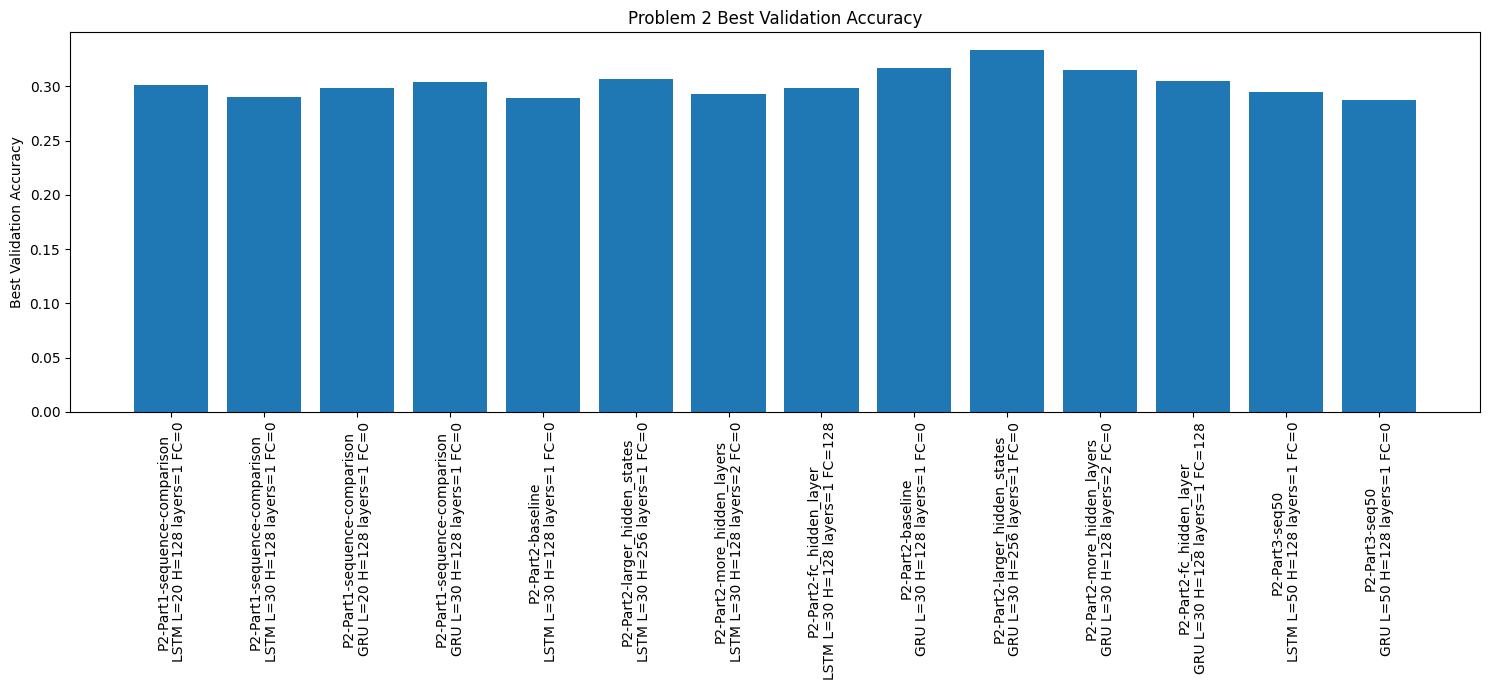

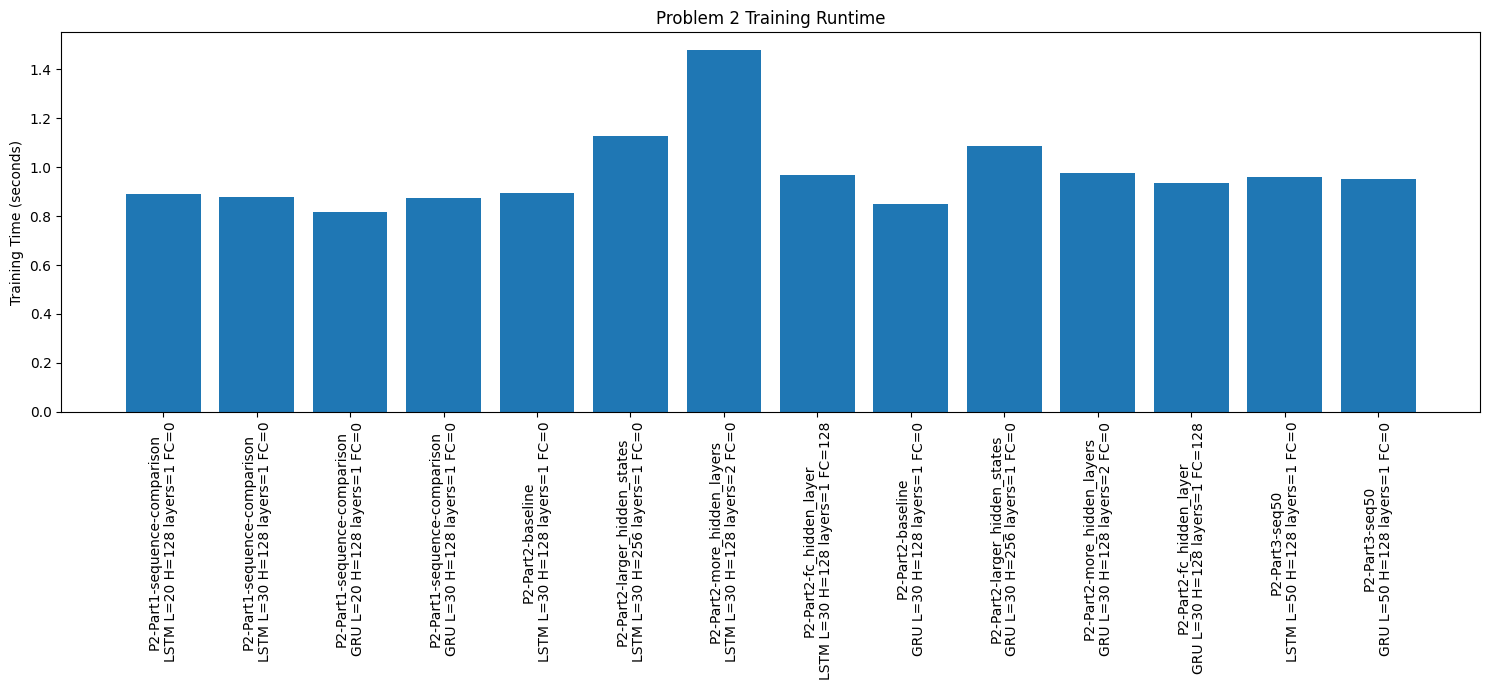

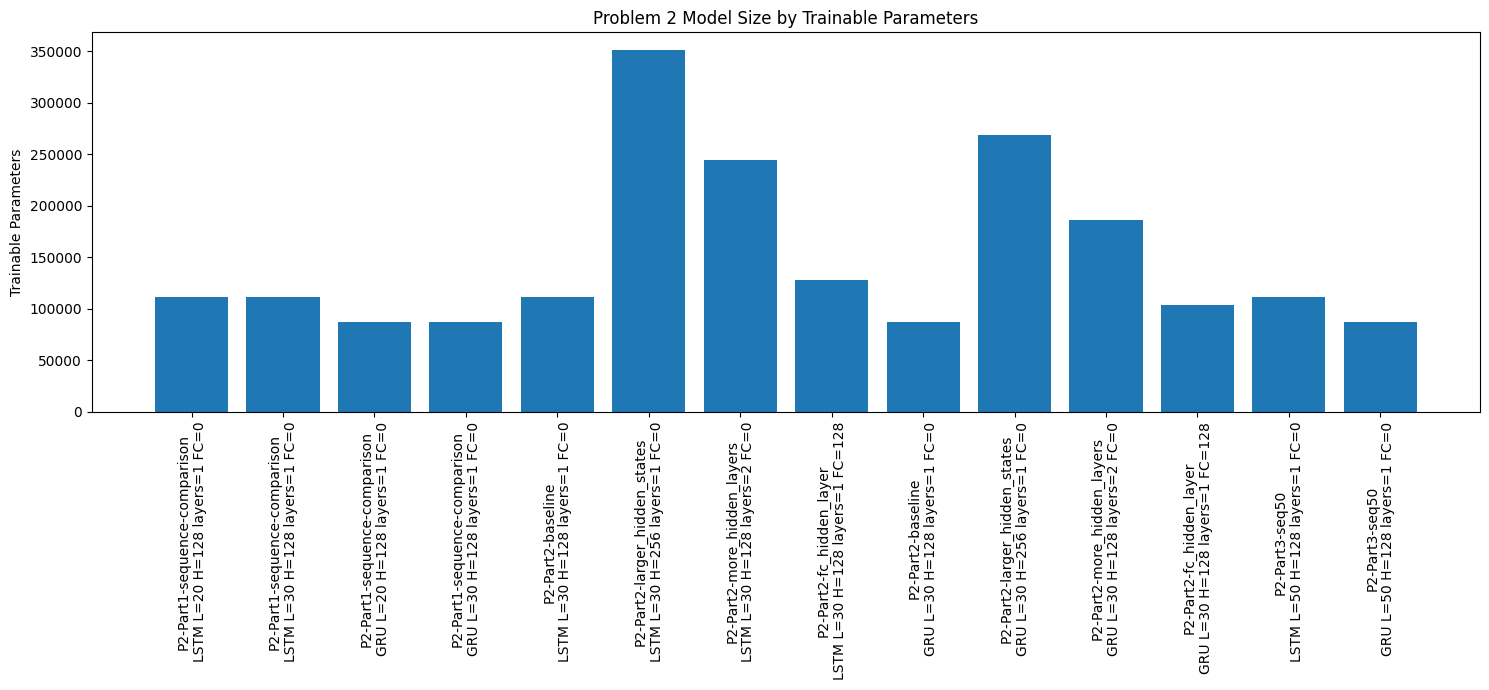

In [25]:
bar_df = summary_df.copy()
bar_df["label"] = (
    bar_df["part"].astype(str)
    + "\n" + bar_df["model_type"].astype(str)
    + " L=" + bar_df["seq_len"].astype(str)
    + " H=" + bar_df["hidden_size"].astype(str)
    + " layers=" + bar_df["num_layers"].astype(str)
    + " FC=" + bar_df["fc_hidden_size"].astype(str)
)

plt.figure(figsize=(15, 7))
plt.bar(bar_df["label"], bar_df["best_val_accuracy"])
plt.xticks(rotation=90)
plt.ylabel("Best Validation Accuracy")
plt.title("Problem 2 Best Validation Accuracy")
plt.tight_layout()
path = OUT_DIR / "problem2_accuracy_bar.png"
plt.savefig(path, dpi=200)
plt.show()

plt.figure(figsize=(15, 7))
plt.bar(bar_df["label"], bar_df["training_time_sec"])
plt.xticks(rotation=90)
plt.ylabel("Training Time (seconds)")
plt.title("Problem 2 Training Runtime")
plt.tight_layout()
path = OUT_DIR / "problem2_runtime_bar.png"
plt.savefig(path, dpi=200)
plt.show()

plt.figure(figsize=(15, 7))
plt.bar(bar_df["label"], bar_df["trainable_parameters"])
plt.xticks(rotation=90)
plt.ylabel("Trainable Parameters")
plt.title("Problem 2 Model Size by Trainable Parameters")
plt.tight_layout()
path = OUT_DIR / "problem2_parameter_bar.png"
plt.savefig(path, dpi=200)
plt.show()

## Step 11 — Display generated text samples

In [26]:
print(samples_txt.read_text(encoding="utf-8")[:6000])

{'part': 'P2-Part1-sequence-comparison', 'model_type': 'LSTM', 'seq_len': 20, 'embedding_dim': 64, 'hidden_size': 128, 'num_layers': 1, 'fc_hidden_size': 0, 'dropout': 0.2}
ROMEO:
Fit thatnse the nse ond ared thare onk, pbecst,
Whe the coat fou lapveist cale burore.

Fithe ust tho yo, be eve dit at mang you. the belllates.
Wer url hat ghe mermachand pof ist disen:-it wurore canse wor rome sey sanveeevst thorest 'ell; hhere that that Be cat the fit derve ste, the ban thanes a

{'part': 'P2-Part1-sequence-comparison', 'model_type': 'LSTM', 'seq_len': 30, 'embedding_dim': 64, 'hidden_size': 128, 'num_layers': 1, 'fc_hidden_size': 0, 'dropout': 0.2}
ROMEO: tho be't lire whemy spe-elpellie the gost nor thiuns thibe goy wocd int tin;


e surire ak s the paws camnede bsves whely sor theasy be on mas arst hat ssot al? you ares pake fien;
I sthit un wntien. his frored ve youbd ye tho the veld

Sersy hat st thi,
Stizer, to;U
Ynour acars. nour ve Soud, hout

{'part': 'P2-Part1-sequence-comparison